In [25]:
import cv2
import os
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [5]:
import os
import cv2
import numpy as np

def UTK_read(path_folder):
    image_list = []
    gender_list = []
    age_list = []

    for file in os.listdir(path_folder):
        try:
            parts = file.split('_')
            if len(parts) < 2:
                continue
            
            gender = int(parts[1])
            age = int(parts[0])

            path_image = os.path.join(path_folder, file)
            image = cv2.imread(path_image)
            
            if image is None:
                continue

            image = cv2.resize(image, (64, 64))
            image = image / 255.0

            image_list.append(image)
            gender_list.append(gender)
            age_list.append(age)

        except Exception as e:
            continue

    X = np.array(image_list)
    y_gender = np.array(gender_list)
    y_age = np.array(age_list)
    return X, y_gender, y_age


In [6]:
utk_folder = '/kaggle/input/genderage-recognition/UTKFace'
X, y_gender, y_age = UTK_read(utk_folder)

In [108]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_age_train, y_age_temp, y_gender_train, y_gender_temp = train_test_split(
    X, y_age, y_gender, test_size=0.30, random_state=42
)

X_val, X_test, y_age_val, y_age_test, y_gender_val, y_gender_test = train_test_split(
    X_temp, y_age_temp, y_gender_temp, test_size=0.50, random_state=42
)

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,     
    height_shift_range=0.1, 
    brightness_range=[0.8, 1.2]
)
datagen.fit(X_train)

min_age = 0
max_age = 100

y_age_train_norm = (y_age_train - min_age) / (max_age - min_age)
y_age_val_norm = (y_age_val - min_age) / (max_age - min_age)
y_age_test_norm = (y_age_test - min_age) / (max_age - min_age)

In [130]:
inputs = Input(shape=(64, 64, 3))

x = Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4))(inputs)
x = Activation('relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(1e-4))(x)
x = Activation('relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(1e-4))(x)
x = Activation('relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

x = Conv2D(256, (3,3), padding='same', kernel_regularizer=l2(1e-4))(x)
x = Activation('relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)


x = Flatten()(x)
x = Dropout(0.3)(x) 

output_gender = Dense(1, activation='sigmoid', name='gender')(x)
output_age = Dense(1, activation='linear', name='age')(x)

model = Model(inputs=inputs, outputs=[output_gender, output_age])

model.compile(
    optimizer='adam',
    loss={'gender': 'binary_crossentropy', 'age': Huber()},
    metrics={'gender': 'accuracy', 'age': 'mae'}
)

model.summary()

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29            │ (None, 64, 64, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_121 (Conv2D)       │ (None, 64, 64, 32)     │            896 │ input_layer_29[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_121            │ (None, 64, 64, 32)     │              0 │ conv2d_121[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_121   │ (None, 64, 64, 32)     │            128 │ activation_121[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_121         │ (None, 32, 32, 32)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_122 (Conv2D)       │ (None, 32, 32, 64)     │         18,496 │ max_pooling2d_121[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_122            │ (None, 32, 32, 64)     │              0 │ conv2d_122[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_122   │ (None, 32, 32, 64)     │            256 │ activation_122[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_122         │ (None, 16, 16, 64)     │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_123 (Conv2D)       │ (None, 16, 16, 128)    │         73,856 │ max_pooling2d_122[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_123            │ (None, 16, 16, 128)    │              0 │ conv2d_123[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_123   │ (None, 16, 16, 128)    │            512 │ activation_123[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_123         │ (None, 8, 8, 128)      │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_124 (Conv2D)       │ (None, 8, 8, 256)      │        295,168 │ max_pooling2d_123[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_124       

 Total params: 398,530 (1.52 MB)

 Trainable params: 397,570 (1.52 MB)

 Non-trainable params: 960 (3.75 KB)

In [131]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train,
    {'gender': y_gender_train, 'age': y_age_train_norm},
    validation_data=(X_val, {'gender': y_gender_val, 'age': y_age_val_norm}),
    epochs=40,
    batch_size=16,
    callbacks=[early_stop, reduce_lr]
)



Epoch 1/40
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - age_loss: 0.7243 - age_mae: 1.1059 - gender_accuracy: 0.7144 - gender_loss: 0.7126 - loss: 1.4702 - val_age_loss: 0.0413 - val_age_mae: 0.2235 - val_gender_accuracy: 0.8383 - val_gender_loss: 0.3835 - val_loss: 0.4630 - learning_rate: 0.0010
Epoch 2/40
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - age_loss: 0.1162 - age_mae: 0.3771 - gender_accuracy: 0.8337 - gender_loss: 0.4029 - loss: 0.5588 - val_age_loss: 0.0355 - val_age_mae: 0.2141 - val_gender_accuracy: 0.8375 - val_gender_loss: 0.4268 - val_loss: 0.5076 - learning_rate: 0.0010
Epoch 3/40
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - age_loss: 0.0526 - age_mae: 0.2565 - gender_accuracy: 0.8617 - gender_loss: 0.3331 - loss: 0.4328 - val_age_loss: 0.0853 - val_age_mae: 0.3609 - val_gender_accuracy: 0.8801 - val_gender_loss: 0.2836 - val_loss: 0.4226 - learning_rate: 0.0010
Epoch 4/40
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - age_loss: 0.0354 - age_mae: 0.2109 - gender_accu

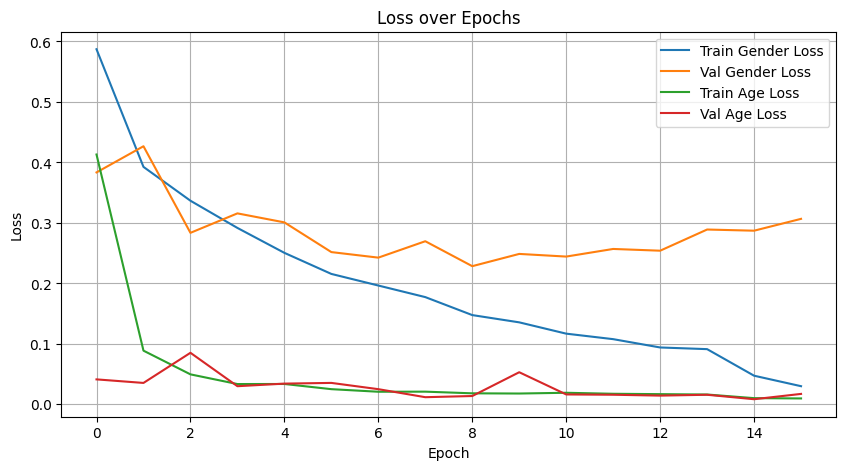

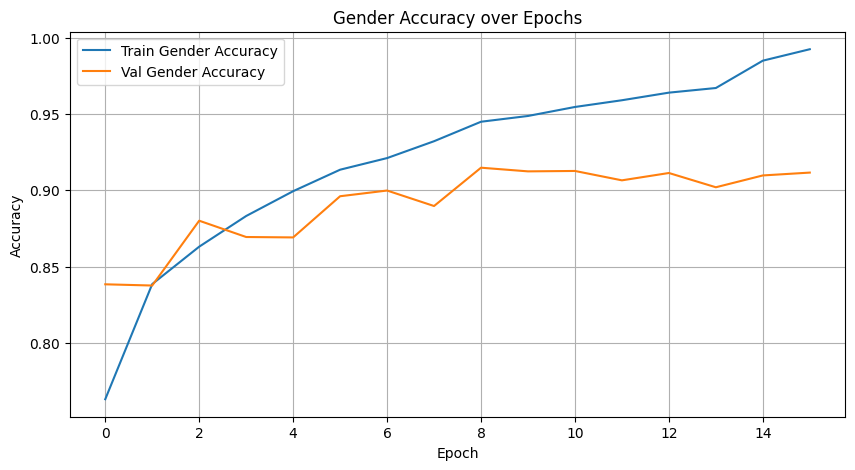

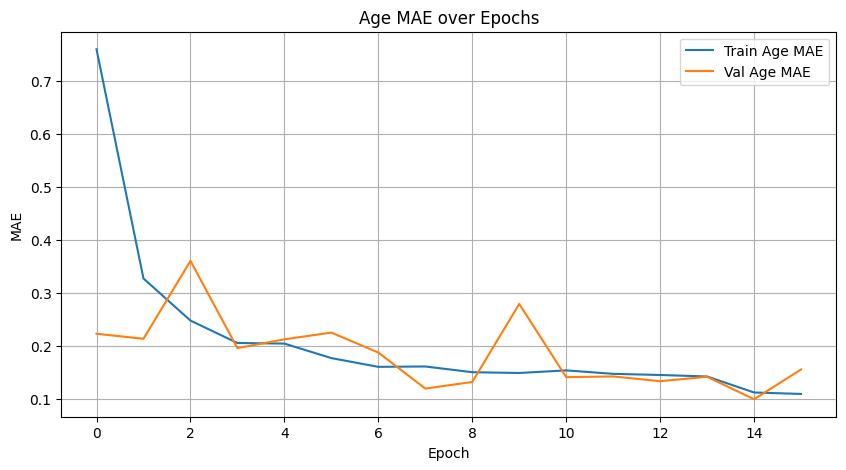

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['gender_loss'], label='Train Gender Loss')
plt.plot(history.history['val_gender_loss'], label='Val Gender Loss')
plt.plot(history.history['age_loss'], label='Train Age Loss')
plt.plot(history.history['val_age_loss'], label='Val Age Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['gender_accuracy'], label='Train Gender Accuracy')
plt.plot(history.history['val_gender_accuracy'], label='Val Gender Accuracy')
plt.title('Gender Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history.history['age_mae'], label='Train Age MAE')
plt.plot(history.history['val_age_mae'], label='Val Age MAE')
plt.title('Age MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()


In [133]:
test_results = model.evaluate(
    X_test,
    {'gender': y_gender_test, 'age': y_age_test_norm},
    batch_size=32,
    verbose=1
)


117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - age_loss: 0.0136 - age_mae: 0.1315 - gender_accuracy: 0.8954 - gender_loss: 0.2654 - loss: 0.3805


In [141]:
model.save('age_gender1.keras')

In [142]:
from tensorflow.keras.models import load_model
model = load_model("age_gender1.keras")

In [144]:
def dudoan(model, path_anh):
    
    img = cv2.imread(path_anh)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    gender_pred, age_pred_norm = model.predict(img)

    gender_label = "Nữ" if gender_pred[0][0] >= 0.5 else "Nam"

    age_pred_norm_clamped = np.clip(age_pred_norm[0][0], 0, 1)

    min_age = 0
    max_age = 100
    age_pred = age_pred_norm_clamped * (max_age - min_age) + min_age
    age_pred = int(round(age_pred))

    print(f"Giới tính: {gender_label}")
    print(f"Tuổi dự đoán: {age_pred}")


dudoan(model, "/kaggle/input/anhdat/Screenshot_2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Giới tính: Nam
Tuổi dự đoán: 17


In [149]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D

inputs = Input(shape=(64, 64, 3))
base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet')

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output_gender = Dense(1, activation='sigmoid', name='gender')(x)
output_age = Dense(1, activation='linear', name='age')(x)

model = Model(inputs=inputs, outputs=[output_gender, output_age])

for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer='adam',
    loss={'gender': 'binary_crossentropy', 'age': Huber()},
    metrics={'gender': 'accuracy', 'age': 'mae'}
)
model.summary()


/tmp/ipykernel_2398/3430147103.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_tensor=inputs, include_top=False, weights='imagenet')


Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33            │ (None, 64, 64, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 32, 32, 32)     │            864 │ input_layer_33[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 32, 32, 32)     │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 32, 32, 32)     │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 32, 32, 32)     │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 32, 32, 32)     │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 32, 32, 32)     │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 32, 32, 16)     │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 32, 32, 16)     │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 32, 32, 96)     │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 32, 32, 96)     │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 32, 32, 96)     │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 33, 33, 96)     │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 16, 16, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

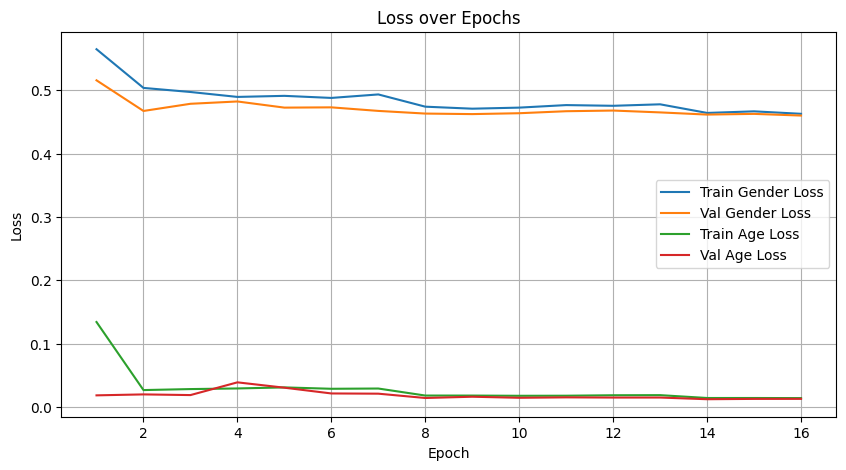

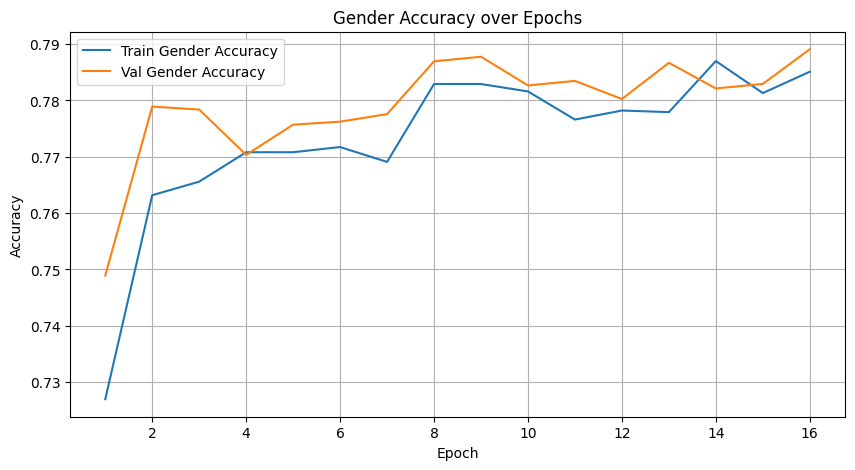

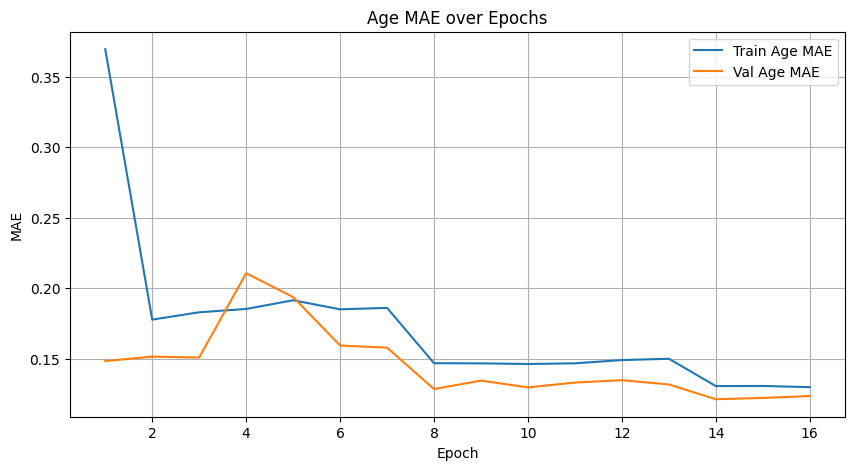

In [157]:
import matplotlib.pyplot as plt

def plot_mobilenetv2_history(history):
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, history.history['gender_loss'], label='Train Gender Loss')
    plt.plot(epochs_range, history.history['val_gender_loss'], label='Val Gender Loss')
    plt.plot(epochs_range, history.history['age_loss'], label='Train Age Loss')
    plt.plot(epochs_range, history.history['val_age_loss'], label='Val Age Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, history.history['gender_accuracy'], label='Train Gender Accuracy')
    plt.plot(epochs_range, history.history['val_gender_accuracy'], label='Val Gender Accuracy')
    plt.title('Gender Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, history.history['age_mae'], label='Train Age MAE')
    plt.plot(epochs_range, history.history['val_age_mae'], label='Val Age MAE')
    plt.title('Age MAE over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_mobilenetv2_history(history)


In [151]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train,
    {'gender': y_gender_train, 'age': y_age_train_norm},
    validation_data=(X_val, {'gender': y_gender_val, 'age': y_age_val_norm}),
    epochs=16,
    batch_size=16,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - age_loss: 0.2755 - age_mae: 0.5805 - gender_accuracy: 0.6926 - gender_loss: 0.6222 - loss: 0.8977 - val_age_loss: 0.0184 - val_age_mae: 0.1484 - val_gender_accuracy: 0.7489 - val_gender_loss: 0.5159 - val_loss: 0.5347 - learning_rate: 0.0010
Epoch 2/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - age_loss: 0.0258 - age_mae: 0.1740 - gender_accuracy: 0.7645 - gender_loss: 0.5053 - loss: 0.5312 - val_age_loss: 0.0199 - val_age_mae: 0.1516 - val_gender_accuracy: 0.7789 - val_gender_loss: 0.4675 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 3/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - age_loss: 0.0275 - age_mae: 0.1804 - gender_accuracy: 0.7656 - gender_loss: 0.4956 - loss: 0.5231 - val_age_loss: 0.0188 - val_age_mae: 0.1509 - val_gender_accuracy: 0.7784 - val_gender_loss: 0.4788 - val_loss: 0.4978 - learning_rate: 0.0010
Epoch 4/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - age_loss: 0.0276 - age_mae: 0.1806 - gender

In [153]:
test_results = model.evaluate(
    X_test,
    {'gender': y_gender_test, 'age': y_age_test_norm},
    batch_size=32,
    verbose=1
)

117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - age_loss: 0.0121 - age_mae: 0.1215 - gender_accuracy: 0.7698 - gender_loss: 0.4795 - loss: 0.4917


In [154]:
model.save('age_gender_mobilenetv2.keras')

In [164]:
from tensorflow.keras.applications import ResNet50

inputs = Input(shape=(64, 64, 3))
base_model = ResNet50(input_tensor=inputs, include_top=False, weights='imagenet')

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)

output_gender = Dense(1, activation='sigmoid', name='gender')(x)
output_age = Dense(1, activation='linear', name='age')(x)

model = Model(inputs=inputs, outputs=[output_gender, output_age])


for layer in base_model.layers:
    layer.trainable = False

model.compile(
    optimizer='adam',
    loss={'gender': 'binary_crossentropy', 'age': Huber()},
    metrics={'gender': 'accuracy', 'age': 'mae'}
)

model.summary()

Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_36            │ (None, 64, 64, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 70, 70, 3)      │              0 │ input_layer_36[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 32, 32, 64)     │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 32, 32, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 32, 32, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 34, 34, 64)     │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 16, 16, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 16, 16, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 16, 16, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 16, 16, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 16, 16, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 16, 16, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 16, 16, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 16, 16, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 16, 16, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [165]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

history = model.fit(
    X_train,
    {'gender': y_gender_train, 'age': y_age_train_norm},
    validation_data=(X_val, {'gender': y_gender_val, 'age': y_age_val_norm}),
    epochs=16,
    batch_size=16,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - age_loss: 0.0378 - age_mae: 0.2052 - gender_accuracy: 0.5446 - gender_loss: 0.6879 - loss: 0.7256 - val_age_loss: 0.0181 - val_age_mae: 0.1498 - val_gender_accuracy: 0.6523 - val_gender_loss: 0.6607 - val_loss: 0.6789 - learning_rate: 0.0010
Epoch 2/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - age_loss: 0.0198 - age_mae: 0.1552 - gender_accuracy: 0.6014 - gender_loss: 0.6662 - loss: 0.6860 - val_age_loss: 0.0179 - val_age_mae: 0.1510 - val_gender_accuracy: 0.6400 - val_gender_loss: 0.6502 - val_loss: 0.6682 - learning_rate: 0.0010
Epoch 3/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - age_loss: 0.0207 - age_mae: 0.1583 - gender_accuracy: 0.6101 - gender_loss: 0.6580 - loss: 0.6786 - val_age_loss: 0.0222 - val_age_mae: 0.1782 - val_gender_accuracy: 0.6453 - val_gender_loss: 0.6412 - val_loss: 0.6634 - learning_rate: 0.0010
Epoch 4/16
1090/1090 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - age_loss: 0.0201 - age_mae: 0.1565 - gende

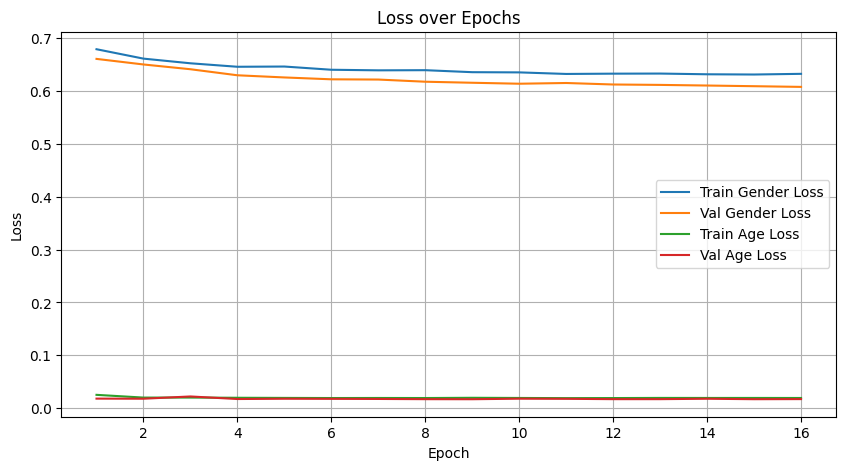

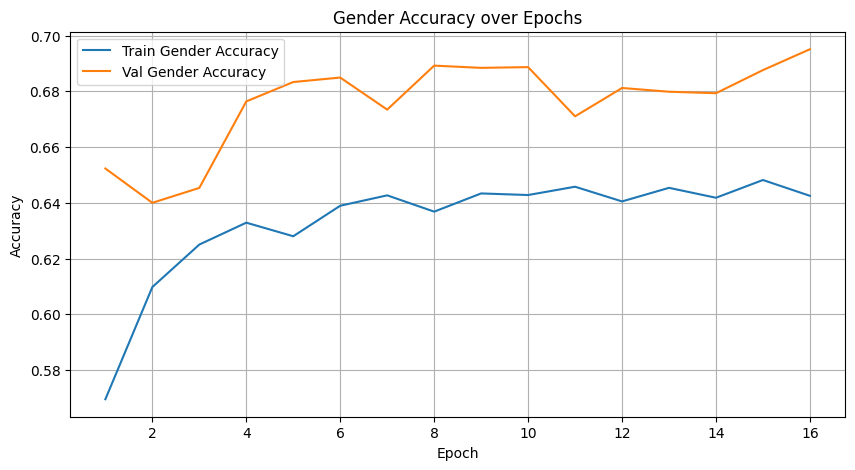

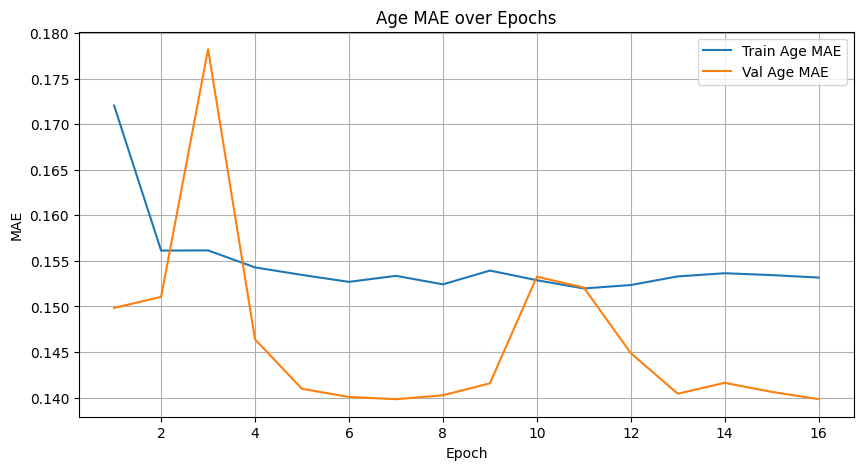

In [166]:
def plot_resnet50_history(history):
    epochs_range = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, history.history['gender_loss'], label='Train Gender Loss')
    plt.plot(epochs_range, history.history['val_gender_loss'], label='Val Gender Loss')
    plt.plot(epochs_range, history.history['age_loss'], label='Train Age Loss')
    plt.plot(epochs_range, history.history['val_age_loss'], label='Val Age Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, history.history['gender_accuracy'], label='Train Gender Accuracy')
    plt.plot(epochs_range, history.history['val_gender_accuracy'], label='Val Gender Accuracy')
    plt.title('Gender Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(epochs_range, history.history['age_mae'], label='Train Age MAE')
    plt.plot(epochs_range, history.history['val_age_mae'], label='Val Age MAE')
    plt.title('Age MAE over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_resnet50_history(history)

In [167]:
test_results = model.evaluate(
    X_test,
    {'gender': y_gender_test, 'age': y_age_test_norm},
    batch_size=32,
    verbose=1
)

117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - age_loss: 0.0175 - age_mae: 0.1427 - gender_accuracy: 0.6819 - gender_loss: 0.6085 - loss: 0.6260


In [168]:
model.save('age_gender_resnet50.keras')